> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** clock drift correction, deck-pressure check, chop deployment/recovery, outlier removal (filtering, thresholding, hand editing).

**To do:** delete the leftover `calculate_CNDC`/plot cells copy-pasted in from notebook 05 (they don't belong here); fix the `24020`/`20420` index mismatch and "fucntion" typo in the chop_deck discussion; minor typo cleanup ("acceptsable", "wpply").

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Postprocessing and QC (Part 1): Chopping and removing outliers

Here, we show some examples of **basic postprocessing functions**: 

- Clock corrections
- Chop deployment and recovery


We also illustrate **outlier removal**:

    - Filtering
    - Thresholding
    - Hand editing

Drift and offset corrections are covered in the next notebook.

In [1]:
from kval.data import moored, edit
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

___

## Load the time series

Let's start by loading the file we produced in [step #2](./02_load_data_rbr_instruments.ipynb).

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_from_raw.nc')

In [3]:
ds = xr.open_dataset(
    '../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_from_raw.nc', 
    decode_cf=False)

> Note: You can also just use xarray's `xarray.open_dataset()` to open NetCDFs (`moored.load_nc` is just a thin wrapper for that function). Note that you may want to specify `decode_cf = False` to avoid `open_dataset()` automatically decoding `TIME` from a float (days since 1970-01-01) to a `datetime64` object.

We will also make a copy of the dataset before applying edits so we can compare:

In [4]:
ds0 = ds.copy(deep = True)

`(deep=True)` makes sure that we are making a copy that will not be affected by any changes we make to `ds`.

___

## Adjust for a known clock drift

The internal clock of the instrument can drift over time while deployed. With modern RBR instruments this rarely amounts to more than some minutes of drift over years of deployment - but we should compensate for the drift in any event.

Once you know the difference between the instrument clock and true time on recovery, we can adjust the time stamp of the instrument to compensate, assuming that time drift occurs linearly over the deployment period.

Whether we correct or not will typically depend on whether we think the correction matters for any scientific application. In general, it is good to apply a correction if you can - it can only make things better.  

Below, we imagine that we have observed that the instrument clock *leads* true time by 2 minutes and 34 seconds.

> *If the instrument clock* lags *true time, use negative values for* `seconds`, `minutes` *etc).*

In [5]:
ds = moored.adjust_time_for_drift(ds, minutes=2, seconds=34)

The updated `ds` should now be corrected so that the instrument clock is in line with true time on recovery.

____

### Check deck pressure

Often, these instrument begins sampling before they are put in the water - and are stopped some time after they are back on deck. We typically want to remove data from recovery and deployment from our analysis. Note, however, that for CTDs, deck measurements provide an opportunity to check that the pressure sensor is working correctly.

Essentially, we expect that `PRES`(*sea pressure*, i.e. absolute pressure minus an offset for atmospheric pressure) should be near zero when the instrument is out of the water. Some deviation is acceptable, and some is expected due to fluctuations in atmospheric pressure. When to correct depends on the accuracy you require; for most oceanographic applications small deviations are expected and acceptable, but if your deck pressure offset differs from zero by more than 1 dbar you may consider making correctgions.

Here, we will simply use the `moored.plot` function, change variable to `PRES`, and zoom in on the start and/or end of the record.

In [6]:
moored.plot(ds)

We only have data *before* deployment - in this case the sea pressure is around 0.1 dbar. We consider this acceptsable and will not wpply any further corrections to pressure.

___

## Remove deployment/deck time



Now we want to chop the time series so as to only include ocean measurements.  

#### Chop by time

If we know when the instrument was deployed/recovered, we can simply chop away measurements before/after a certain time stamp.

In the following example, we chop away all measurements after 14:00 UTC, Apr 17 2022:

In [7]:
ds = moored.chop_by_time(ds, end_time = '2022-04-17 14:00')

Chopped dataset to time range start to 2022-04-17 14:00, reducing from 23903 to 22987 samples.


We can also try to detect recovery/deployment based on the pressure data. This usually works, but not always - so make sure you instect the chop before applying it. 

`moored.chop_deck` tries to detect which time period to include by looking for the first/last measurements where pressure is within a SD of the median. 

The user is shown the proposed cut and can choose to decline or execute by entering `y` or `n`.

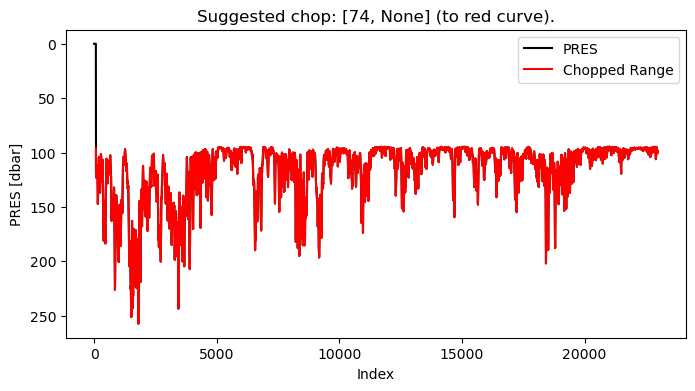

Suggested chop: [74, None] (to red curve).


Accept (y/n)?:  y


Chopping to index: [np.int64(74), None]
Chopped 74 samples using -> [np.int64(74), None] (total samples 22987 -> 22913)


In [8]:
ds = moored.chop_deck(ds, auto_accept=False)

Note that you can also choose to automatically accept the cut by setting `auto_accept = True`. Useful if you are already sure that the fucntion does what you want.


`ds = moored.chop_deck(ds, indices= (200, 24020))` will retain only measurements between indices 200 and 20420.

## Remove outliers

(Note here: We wont actualøly apply these, its just examples. If you were working on an actual datasets and wanter persiostent changes, do ds = func(ds); we do ds_filtered = func(ds)..)

### Filtering

Removed 9 points from PSAL after despiking along dimension TIME.


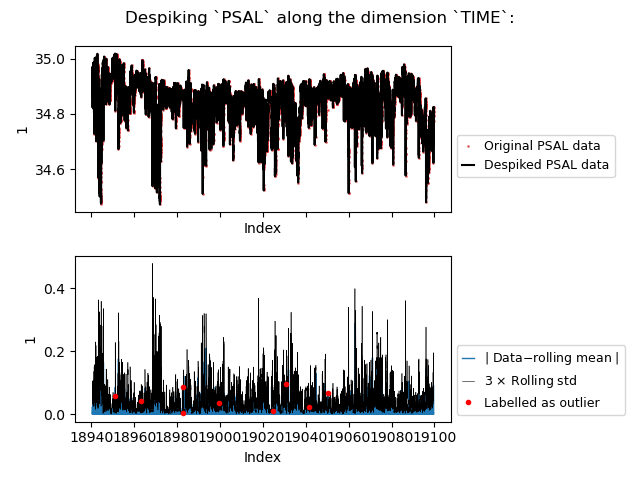

In [10]:
ds = moored.despike_rolling(ds, variable='PSAL', window_size=9, n_std=3, plot = True, verbose = True)

### Save to nc

We will save the file as it now is.

In [15]:
moored.to_netcdf(ds, '../../data/moored_CTD_test_data/intermediate_data/', 'AT800_21_22_CONCERTO_60595_99m_edited.nc')

Updated history attribute. Current content:
---
2021-11-08 - 2022-04-24: Data collection.
2026-09-18: Data read from .rsk file to xarray Dataset using pyRSKtools+kval.
2026-09-20: Creation of this netcdf file.
---
Exported NetCDF file as: ../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc


## Other outlier editing 

(we won't apply thresholding or hand editing in out case, just showing some examples below)

### Thresholding

In [16]:
ds_thr = moored.threshold_pick(ds)

### Hand editing

Output()

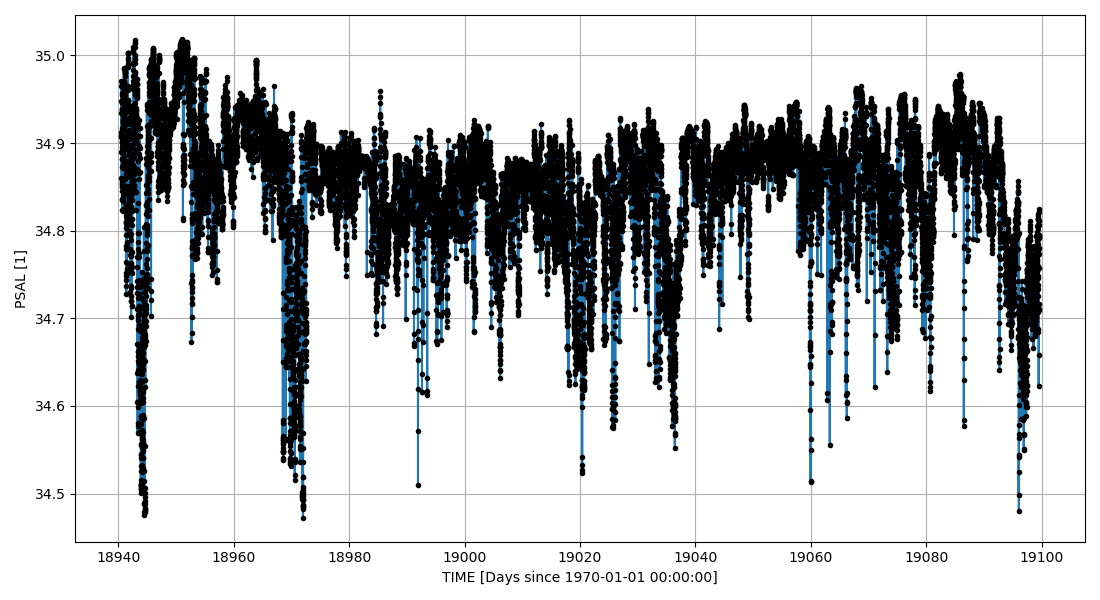

In [34]:
ds_handedit = moored.hand_remove_points(ds, 'PSAL')